### punto 4

In [1]:
!pip install control

In [2]:
# Modelo del sistema y respuestas impulso/escalón
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
from control.matlab import *   # funciones estilo MATLAB

In [3]:
# Parámetros del sistema
R = 0.5
Cs = 2
Cp = 0.2

# Funciones de transferencia
# X(s) = G1(s)F(s) - G2(s)Fo(s)

# G1(s) = (Cs*Cp*R*s + Cp) / ((R*Cs + R*Cp)*s + 1)
num_G1 = [Cs*Cp*R, Cp]
den_G1 = [R*Cs + R*Cp, 1]
G1 = tf(num_G1, den_G1)

# G2(s) = (Cp) / ((R*Cs + R*Cp)*s + 1)
num_G2 = [Cp]
den_G2 = [R*Cs + R*Cp, 1]
G2 = tf(num_G2, den_G2)

print("G1(s) =", G1)
print(" ")
print("G2(s) =", G2)

G1(s) = <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.2 s + 0.2
  -----------
   1.1 s + 1
 
G2(s) = <TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     0.2
  ---------
  1.1 s + 1


#### Respuesta al Impulso

c:\Users\USUARIO\anaconda3\Lib\site-packages\control\timeresp.py:2015: UserWarning: System has direct feedthrough: `D != 0`. The infinite impulse at `t=0` does not appear in the output.
Results may be meaningless!
  warnings.warn("System has direct feedthrough: `D != 0`. The "


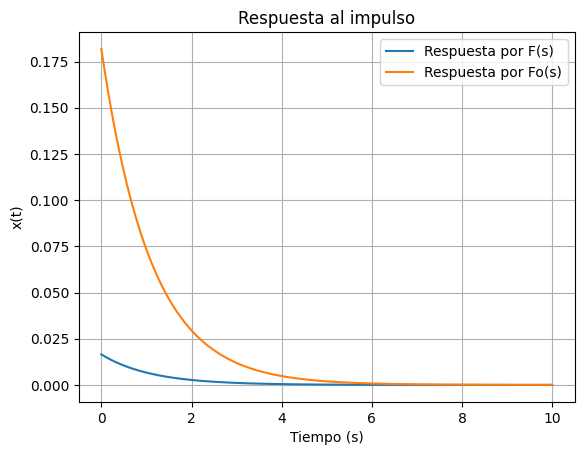

In [4]:
t = np.linspace(0, 10, 1000)

# --- Escalón ---
y1, t1 = impulse(G1, T=t)
y2, t2 = impulse(G2, T=t)
plt.figure(1)
plt.plot(t1, y1, label="Respuesta por F(s)")
plt.plot(t2, y2, label="Respuesta por Fo(s)")

plt.title("Respuesta al impulso")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

#### Respuesta al Escalon

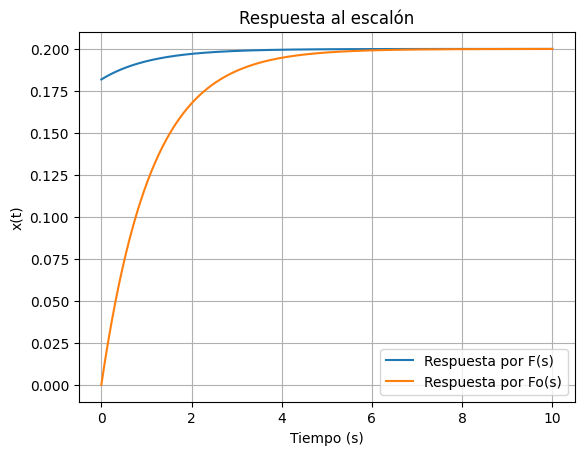

In [5]:
# Respuesta al escalón

# --- Escalón ---
y1, t1 = step(G1, T=t)
y2, t2 = step(G2, T=t)
plt.figure(1)
plt.plot(t1, y1, label="Respuesta por F(s)")
plt.plot(t2, y2, label="Respuesta por Fo(s)")

plt.title("Respuesta al escalón")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

plt.show()

In [32]:
# Tiempo de muestreo
Ts = 0.11

# Transformada Z (discretización)
G1z = c2d(G1, Ts, method='zoh')
G2z = c2d(G2, Ts, method='zoh')

print("\nG1(z) =")
print(G1z)

print("\nG2(z) =")
print(G2z)



G1(z) =
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.11

  0.1818 z - 0.1628
  -----------------
     z - 0.9048

G2(z) =
<TransferFunction>: sys[1]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.11

   0.01903
  ----------
  z - 0.9048


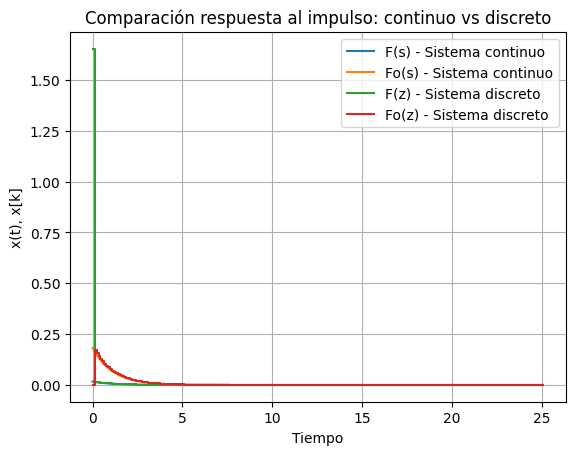

In [37]:
# Respuesta impulso continua
t_imp_s, y_imp_s = ctrl.impulse_response(G1)
t2_imp_s, y2_imp_s = ctrl.impulse_response(G2)

# Respuesta impulso discreta
t_imp_z, y_imp_z = ctrl.impulse_response(G1z)
t2_imp_z, y2_imp_z = ctrl.impulse_response(G2z)

plt.figure(3)

# Sistema continuo
plt.plot(t_imp_s, y_imp_s, label="F(s) - Sistema continuo")
plt.plot(t2_imp_s, y2_imp_s, label="Fo(s) - Sistema continuo")

# Sistema discreto
plt.step(t_imp_z, y_imp_z, where="post", label="F(z) - Sistema discreto")
plt.step(t2_imp_z, y2_imp_z, where="post", label="Fo(z) - Sistema discreto")

plt.title("Comparación respuesta al impulso: continuo vs discreto")
plt.xlabel("Tiempo")
plt.ylabel("x(t), x[k]")
plt.legend()
plt.grid()

plt.show()

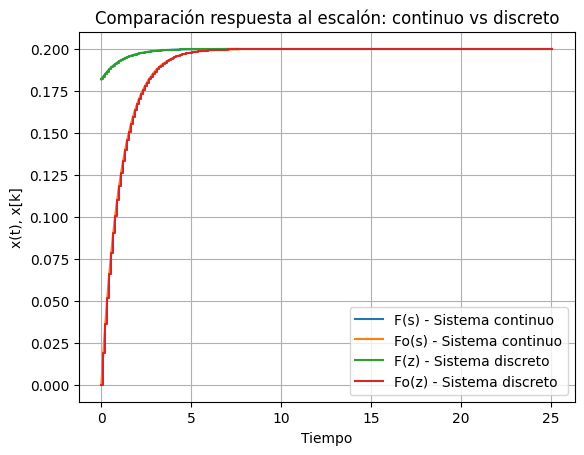

In [38]:
# Respuesta escalón (comparación continuo vs discreto)

t_step, y_step = ctrl.step_response(G1z)
t2_step, y2_step = ctrl.step_response(G2z)

# Sistema continuo
t_step_s, y_step_s = ctrl.step_response(G1)
t2_step_s, y2_step_s = ctrl.step_response(G2)

plt.figure(4)

# Sistema continuo
plt.plot(t_step_s, y_step_s, label="F(s) - Sistema continuo")
plt.plot(t2_step_s, y2_step_s, label="Fo(s) - Sistema continuo")

# Sistema discreto
plt.step(t_step, y_step, where="post", label="F(z) - Sistema discreto")
plt.step(t2_step, y2_step, where="post", label="Fo(z) - Sistema discreto")

plt.title("Comparación respuesta al escalón: continuo vs discreto")
plt.xlabel("Tiempo")
plt.ylabel("x(t), x[k]")
plt.legend()
plt.grid()

plt.show()

## Patologias Musculares

#### Miastenia Gravis

In [ ]:
# Nuevos parametros del sistema
R = 0.5
Cs = 2
Cp = 0.15 # Que es 25% menor que el valor normal

num_G1_m = [Cs*Cp*R, Cp]
den_G1_m = [R*Cs + R*Cp, 1]

# G2(s) = (Cp) / ((R*Cs + R*Cp)*s + 1)
num_G2_m = [Cp]
den_G2_m = [R*Cs + R*Cp, 1]

G1_m = tf(num_G1_m, den_G1_m)
G2_m = tf(num_G2_m, den_G2_m)

print("G1(s) =", G1_m)
print(" ")
print("G2(s) =", G2_m)

G1(s) = <TransferFunction>: sys[66]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.15 s + 0.15
  -------------
   1.075 s + 1
 
G2(s) = <TransferFunction>: sys[67]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     0.15
  -----------
  1.075 s + 1


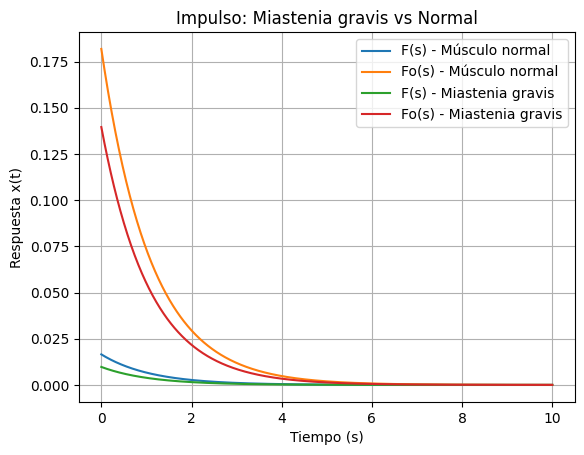

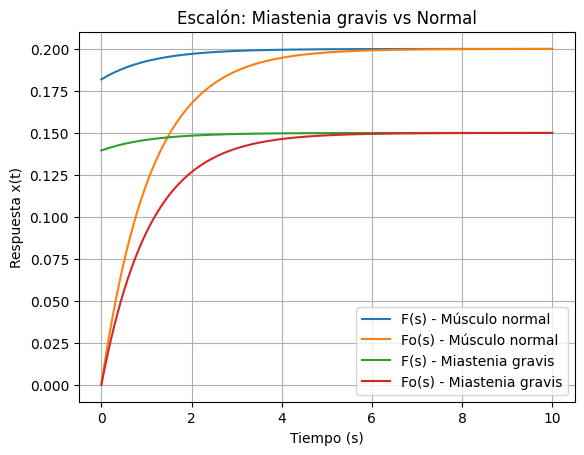

In [17]:
#### Respuesta al Impulso
t = np.linspace(0, 10, 1000)

# --- Impulso ---
y1_m, t1_m = impulse(G1_m, T=t)
y2_m, t2_m = impulse(G2_m, T=t)

plt.figure()

plt.plot(t1, y1, label="F(s) - Músculo normal")
plt.plot(t2, y2, label="Fo(s) - Músculo normal")

plt.plot(t1_m, y1_m, label="F(s) - Miastenia gravis")
plt.plot(t2_m, y2_m, label="Fo(s) - Miastenia gravis")

plt.title("Impulso: Miastenia gravis vs Normal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Respuesta x(t)")
plt.legend()
plt.grid()

plt.show()


#### Respuesta al Escalón

# --- Escalón ---
y1s, t1s = step(G1, T=t)
y2s, t2s = step(G2, T=t)

y1s_m, t1s_m = step(G1_m, T=t)
y2s_m, t2s_m = step(G2_m, T=t)

plt.figure()

plt.plot(t1s, y1s, label="F(s) - Músculo normal")
plt.plot(t2s, y2s, label="Fo(s) - Músculo normal")

plt.plot(t1s_m, y1s_m, label="F(s) - Miastenia gravis")
plt.plot(t2s_m, y2s_m, label="Fo(s) - Miastenia gravis")

plt.title("Escalón: Miastenia gravis vs Normal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Respuesta x(t)")
plt.legend()
plt.grid()

plt.show()

### Distrofia Muscular 

In [19]:
# Parámetros del sistema para simulación de Distrofia Muscular

R_dm = 1.0        # aumento de viscosidad (≈100% mayor que el valor normal 0.5)
Cs_dm = 1.0       # reducción de elasticidad estructural (≈50% menor que 2)
Cp_dm = 0.10      # reducción de capacidad contráctil (≈50% menor que 0.2)

num_G1_dm = [Cs_dm * Cp_dm * R_dm, Cp_dm]
den_G1_dm = [R_dm * Cs_dm + R_dm * Cp_dm, 1]

# G2(s) = (Cp) / ((R*Cs + R*Cp)*s + 1)
num_G2_dm = [Cp]
den_G2_dm = [R_dm * Cs_dm + R_dm * Cp_dm, 1]

G1_dm = tf(num_G1_dm, den_G1_dm)
G2_dm = tf(num_G2_dm, den_G2_dm)

print("G1_distrofia(s) =", G1_dm)
print(" ")
print("G2_distrofia(s) =", G2_dm)

G1_distrofia(s) = <TransferFunction>: sys[64]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.1 s + 0.1
  -----------
   1.1 s + 1
 
G2_distrofia(s) = <TransferFunction>: sys[65]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.15
  ---------
  1.1 s + 1


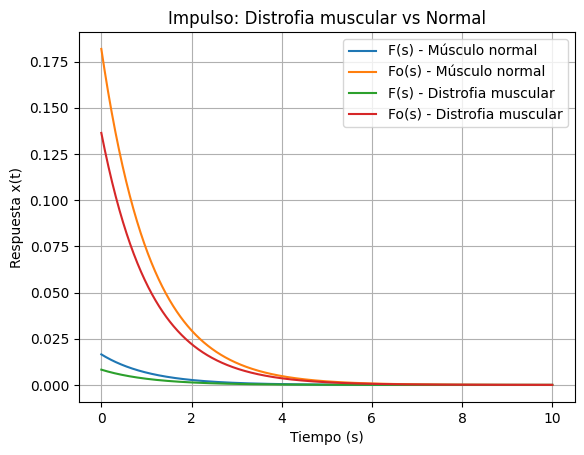

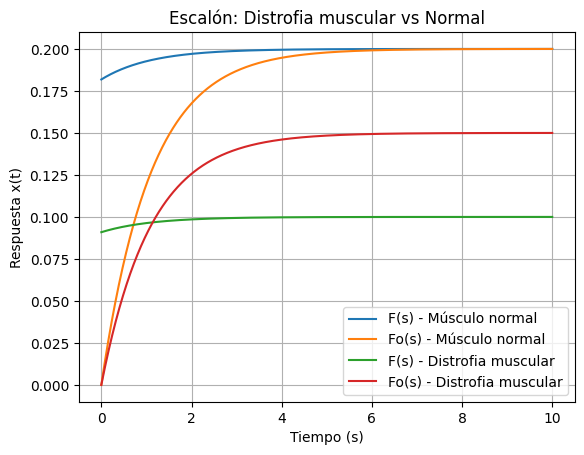

In [18]:
#### Tiempo de simulación
t_dm = np.linspace(0, 10, 1000)

#### Respuesta al Impulso - Distrofia Muscular

y1_dm, t1_dm = impulse(G1_dm, T=t_dm)
y2_dm, t2_dm = impulse(G2_dm, T=t_dm)

plt.figure()

plt.plot(t1, y1, label="F(s) - Músculo normal")
plt.plot(t2, y2, label="Fo(s) - Músculo normal")

plt.plot(t1_dm, y1_dm, label="F(s) - Distrofia muscular")
plt.plot(t2_dm, y2_dm, label="Fo(s) - Distrofia muscular")

plt.title("Impulso: Distrofia muscular vs Normal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Respuesta x(t)")
plt.legend()
plt.grid()

plt.show()


#### Respuesta al Escalón - Distrofia Muscular

y1s, t1s = step(G1, T=t_dm)
y2s, t2s = step(G2, T=t_dm)

y1s_dm, t1s_dm = step(G1_dm, T=t_dm)
y2s_dm, t2s_dm = step(G2_dm, T=t_dm)

plt.figure()

plt.plot(t1s, y1s, label="F(s) - Músculo normal")
plt.plot(t2s, y2s, label="Fo(s) - Músculo normal")

plt.plot(t1s_dm, y1s_dm, label="F(s) - Distrofia muscular")
plt.plot(t2s_dm, y2s_dm, label="Fo(s) - Distrofia muscular")

plt.title("Escalón: Distrofia muscular vs Normal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Respuesta x(t)")
plt.legend()
plt.grid()

plt.show()